In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.activations import selu
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.metrics import RootMeanSquaredError,MeanAbsolutePercentageError
from tensorflow.keras.losses import LogCosh,MeanSquaredError,MeanAbsoluteError,MeanSquaredLogarithmicError
import os
from tensorflow.keras.models import load_model
import matplotlib.dates as mdates
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
import json
class MetricsCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath, monitor='val_root_mean_squared_error', mode='min'):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.best = None
        self.mode = mode
        if self.mode == 'min':
            self.compare = lambda a, b: a < b
            self.best = float('inf')
        else:
            self.compare = lambda a, b: a > b
            self.best = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        if self.compare(current, self.best):
            self.best = current
            # Сохраняем все текущие метрики эпохи в JSON
            with open(self.filepath, 'w', encoding='utf-8') as f:
                json.dump({key: float(value) for key, value in logs.items()}, f, ensure_ascii=False, indent=4)
            print(f"\nМетрики для лучшей модели сохранены в {self.filepath} на эпохе {epoch+1}")


In [3]:
def plot_history_errors(history, train_key=None, val_key=None, title='Training / validation error'):
    if history is None:
        raise ValueError("history == None: нет истории обучения, график построить нельзя")

    keys = list(history.history.keys())
    print("history keys:", keys)

    # выбор ключей для train
    if train_key is None:
        if 'root_mean_squared_error' in keys:
            train_key = 'root_mean_squared_error'
        elif 'loss' in keys:
            train_key = 'loss'
        else:
            raise ValueError("Не найден ключ для train ошибки в history.history")

    # выбор ключей для val
    if val_key is None:
        if 'val_root_mean_squared_error' in keys:
            val_key = 'val_root_mean_squared_error'
        elif 'val_loss' in keys:
            val_key = 'val_loss'
        else:
            raise ValueError("Не найден ключ для val ошибки в history.history")

    train_err = history.history[train_key]
    val_err   = history.history[val_key]

    # --- отдельный график train ---
    plt.figure(figsize=(8, 4))
    plt.plot(train_err, color='black')
    plt.xlabel('epoch')
    plt.ylabel('error')
    plt.title(f'{title} - train')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- отдельный график test/val ---
    plt.figure(figsize=(8, 4))
    plt.plot(val_err, color='gray')
    plt.xlabel('epoch')
    plt.ylabel('error')
    plt.title(f'{title} - test')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [4]:
print("загрузка данных...")
data = pd.read_csv('bitcoin_2017_to_2023.csv')

print(f"Колонки в данных: {list(data.columns)}")

data['timestamp'] = pd.to_datetime(data['timestamp'])

data = data.sort_values('timestamp').reset_index(drop=True)
data1=data
print(f"период данных: {data['timestamp'].min()} до {data['timestamp'].max()}")
print(f"период данных: {data1['timestamp'].min()} до {data1['timestamp'].max()}")
print(f"частота данных: {pd.infer_freq(data['timestamp'][:10])}")


загрузка данных...
Колонки в данных: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']
период данных: 2017-08-17 04:00:00 до 2023-08-01 13:19:00
период данных: 2017-08-17 04:00:00 до 2023-08-01 13:19:00
частота данных: min


In [5]:
from sklearn.preprocessing import StandardScaler

features = ['timestamp', 'open', 'high', 'close', 'volume',
            'quote_asset_volume', 'number_of_trades',
            'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

data['timestamp'] = pd.to_datetime(data['timestamp'])
data['timestamp'] = data['timestamp'].astype('int64')  # числовое представление даты

X = data[features]
y = data['low']

train_size = 40000
X_train = X.iloc[:train_size].copy()
X_test  = X.iloc[train_size:train_size + 10000].copy()
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:train_size + 10000]

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

X_train_num = X_train[features_num].values
X_test_num  = X_test[features_num].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0],
                                      X_train_scaled.shape[1],
                                      1).astype('float32')
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],
                                     X_test_scaled.shape[1],
                                     1).astype('float32')

print("X_train_lstm shape:", X_train_lstm.shape)  # (160000, 9, 1)
print("X_test_lstm shape:", X_test_lstm.shape)   # (40000, 9, 1)


X_train_lstm shape: (40000, 9, 1)
X_test_lstm shape: (10000, 9, 1)


In [6]:
model_path = 'best_model_50.keras'
metrics_path = 'best_model_metrics_50.json'

if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())
    print("Оценка на тесте:")
else:
    print("Обучаем новую модель с LSTM...")

    model = Sequential([
        LSTM(16, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.17),
        LSTM(16, return_sequences=False, activation='relu'),
        Dropout(0.17),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(learning_rate=0.001),
        loss=LogCosh(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(metrics_path, monitor='val_root_mean_squared_error', mode='min')

    history = model.fit(
        X_train_lstm, y_train,
        epochs=488,
        batch_size=216,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

Загружаем существующую обученную модель...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 9, 16)          │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,846 (38.46 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,565 (25.65 KB)

None
Оценка на тесте:


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


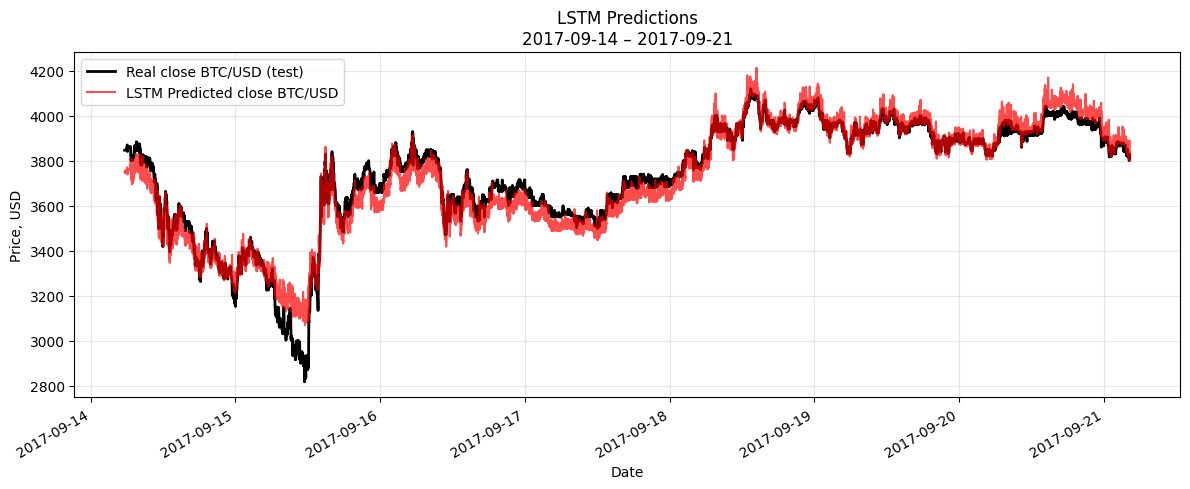

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 3069.09 - 4212.87
y_real range: 2817.00 - 4119.50


In [7]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


In [8]:
model_path = 'best_model_2_50.keras'
metrics_path = 'best_model_2_metrics_50.json'
history = None
if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())         
    print("Оценка на тесте:")
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(26, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.19),
        LSTM(26, return_sequences=False, activation='linear'),
        Dropout(0.19),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(),
        loss=LogCosh(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=310,
        batch_size=100,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='MSE model, RMSE over epochs')
else:
    print("Модель загружена из файла: history нет, график по эпохам построить нельзя.")

Загружаем существующую обученную модель...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 9, 26)          │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 26)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 26)             │         5,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,356 (99.05 KB)

 Trainable params: 8,451 (33.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,905 (66.04 KB)

None
Оценка на тесте:
Модель загружена из файла: history нет, график по эпохам построить нельзя.


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


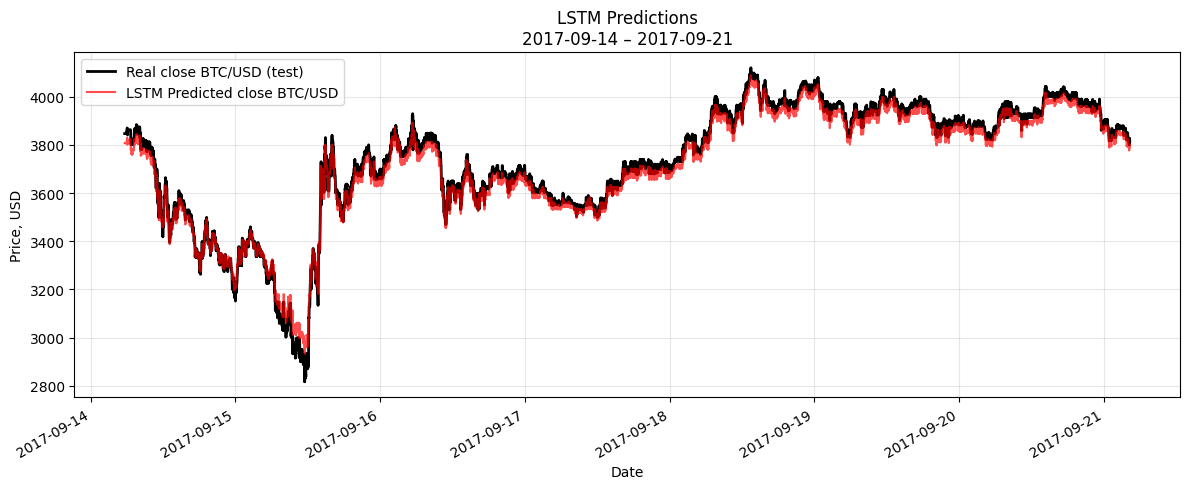

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 2932.24 - 4088.94
y_real range: 2817.00 - 4119.50


In [9]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


In [10]:
model_path = 'best_model_3_50.keras'
metrics_path = 'best_model_3_metrics_50.json'
history = None
if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())              # структура модели
    print("Оценка на тесте:")
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(6, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.03),
        LSTM(6, return_sequences=False, activation='linear'),
        Dropout(0.03),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(),
        loss=MeanSquaredError(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=381,
        batch_size=80,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='MSE model, RMSE over epochs')
else:
    print("Модель загружена из файла: history нет, график по эпохам построить нельзя.")


Загружаем существующую обученную модель...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 9, 6)           │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 9, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 6)              │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,536 (6.00 KB)

 Trainable params: 511 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,025 (4.01 KB)

None
Оценка на тесте:
Модель загружена из файла: history нет, график по эпохам построить нельзя.


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


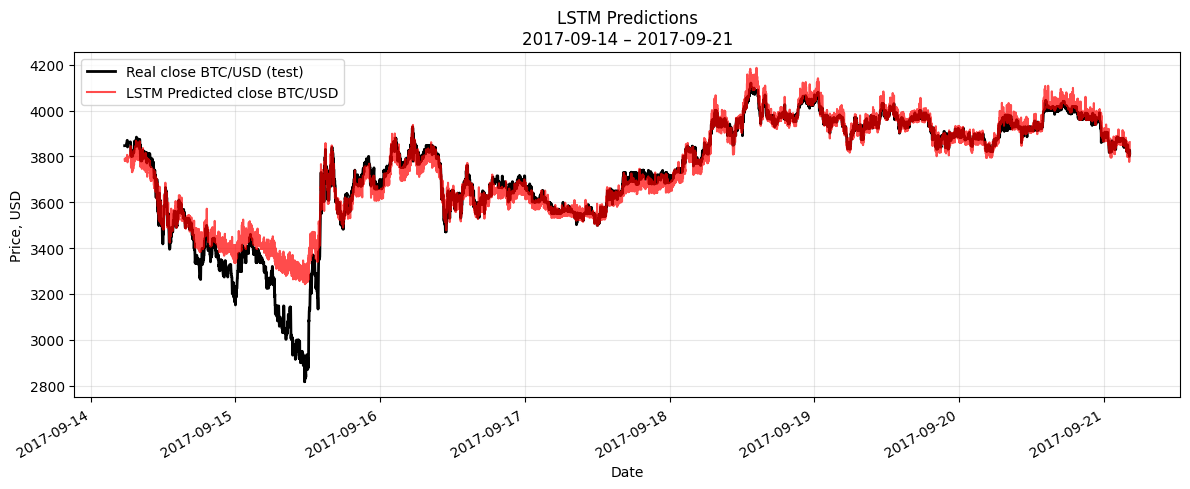

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 3242.65 - 4186.08
y_real range: 2817.00 - 4119.50


In [11]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


In [12]:
model_path = 'best_model_4_50.keras'
metrics_path = 'best_model_4_metrics_50.json'
history = None
if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())         
    print("Оценка на тесте:")
    eval_res = model.evaluate(X_test, y_test, verbose=0)
    print("loss =", eval_res[0])
    if len(eval_res) > 1:
        print("RMSE =", eval_res[1])
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(14, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.08),
        LSTM(14, return_sequences=False, activation='linear'),
        Dropout(0.08),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(),
        loss=MeanSquaredError(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=373,
        batch_size=80,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='best_model_4: MSE / RMSE over epochs')
else:
    print("Модель загружена из файла: history отсутствует, "
          "поэтому график обучения по эпохам в этом запуске построить нельзя.")


Загружаем существующую обученную модель...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 9, 14)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 9, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 14)             │         1,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,608 (29.72 KB)

 Trainable params: 2,535 (9.90 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,073 (19.82 KB)

None
Оценка на тесте:
loss = 22473280.0
RMSE = 4740.59912109375
Модель загружена из файла: history отсутствует, поэтому график обучения по эпохам в этом запуске построить нельзя.


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


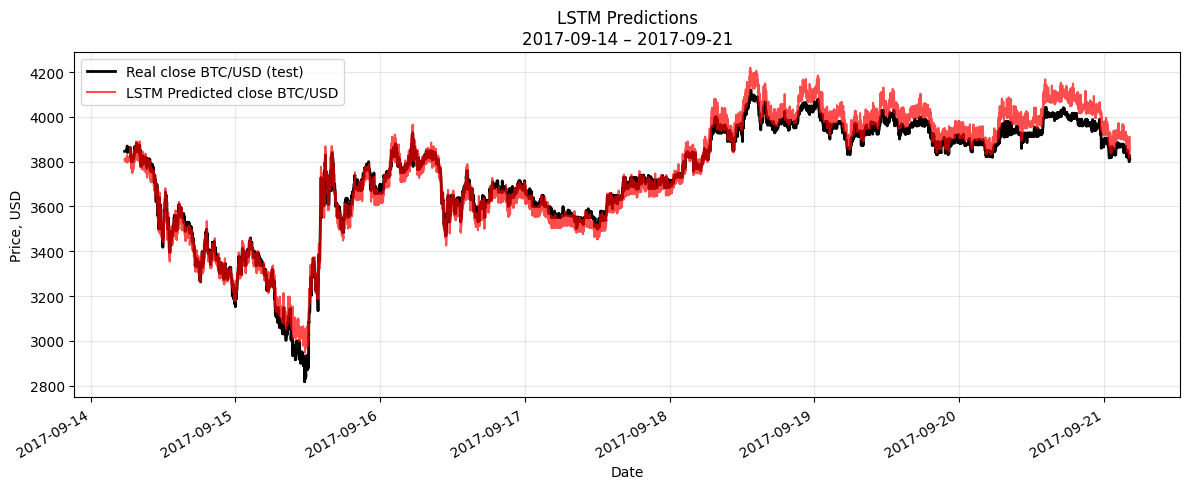

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 2946.53 - 4219.47
y_real range: 2817.00 - 4119.50


In [13]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


In [14]:
model_path = 'best_model_5_50.keras'
metrics_path = 'best_model_5_metrics_50.json'
history = None

if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(5, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.11),
        LSTM(5, return_sequences=False, activation='tanh'),
        Dropout(0.11),
        Dense(1)
    ])

    model.compile(
        optimizer='Adadelta',
        loss=MeanAbsoluteError(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=494,
        batch_size=110,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='best_model_5: MAE / RMSE over epochs')
else:
    print("Модель загружена из файла: history отсутствует, "
          "поэтому график обучения по эпохам в этом запуске построить нельзя.")


Загружаем существующую обученную модель...
Модель загружена из файла: history отсутствует, поэтому график обучения по эпохам в этом запуске построить нельзя.


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


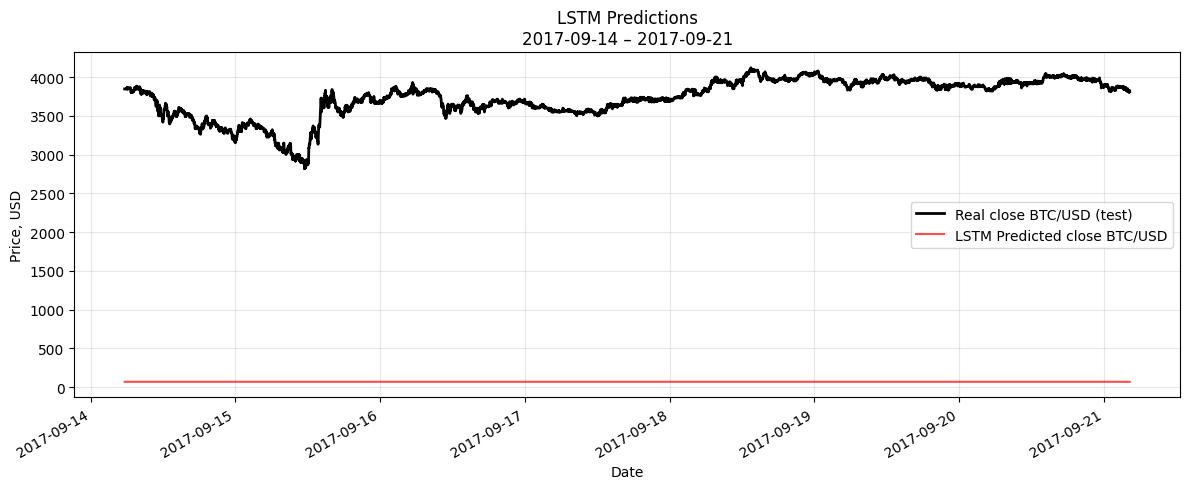

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 68.76 - 68.78
y_real range: 2817.00 - 4119.50


In [15]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values  

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


In [16]:
import glob
import re
metrics_files = glob.glob("*_metrics_50.json")

models = {}

for file in metrics_files:
    if os.path.exists(file):
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
            match = re.search(r'best_model_(\d+)', file)
            if match:
                model_num = int(match.group(1))
            else:
                model_num = 1
            
            models[model_num] = {
                'file': file,
                'val_rmse': data['val_root_mean_squared_error'],
                'val_mae': data['val_mae'],
                'val_mape': data['val_mape'],
                'val_r2': data['val_r2'],
                'val_loss':data['val_loss']
            }

sorted_models = sorted(models.items(), key=lambda x: x[1]['val_rmse'])

print("\n" + "="*70)
print("Рейтинг моделей по val_RMSE")
print("="*70)
print(f"{'#':<3} {'Модель':<8} {'Файл':<30} {'val_rmse':<12} {'val_r2':<10}")
print("-"*70)

for rank, (model_num, info) in enumerate(sorted_models, 1):
    print(f"{rank:<3} #{model_num:<7} {info['file']:<30} {info['val_rmse']:<12.3f} {info['val_r2']:<10.3f}")

print("\n" + "ЛУЧШАЯ МОДЕЛЬ")
best_model_num = sorted_models[0][0]
best_info = sorted_models[0][1]
print(f"Модель #{best_model_num}")
print(f"Файл: {best_info['file']}")
print(f"val_rmse: {best_info['val_rmse']:.3f}")
print(f"val_mae:  {best_info['val_mae']:.3f}")
print(f"val_mape: {best_info['val_mape']:.3f}")
print(f"val_r2:   {best_info['val_r2']:.3f}")
print(f"val_loss:   {best_info['val_loss']:.3f}")




Рейтинг моделей по val_RMSE
#   Модель   Файл                           val_rmse     val_r2    
----------------------------------------------------------------------
1   #2       best_model_2_metrics_50.json   29.015       0.986     
2   #4       best_model_4_metrics_50.json   47.431       0.963     
3   #1       best_model_metrics_50.json     57.446       0.945     
4   #3       best_model_3_metrics_50.json   71.345       0.916     
5   #5       best_model_5_metrics_50.json   3673.159     -222.587  

ЛУЧШАЯ МОДЕЛЬ
Модель #2
Файл: best_model_2_metrics_50.json
val_rmse: 29.015
val_mae:  25.926
val_mape: 0.700
val_r2:   0.986
val_loss:   25.238


In [17]:
#2 дня
X = data1[features].copy()
X['timestamp'] = pd.to_datetime(X['timestamp']).astype('int64') // 1_000_000

y = data1['low']
train_size = 40000
test_size = 10000
future_size = 2881

train_end = train_size
test_end = train_size + test_size
future_end = train_size + test_size + future_size

X_future = X.iloc[train_size + test_size:train_size + test_size + future_size].copy()
y_future = y.iloc[train_size + test_size:train_size + test_size + future_size]

X_future_num = X_future[features_num].values
X_future_scaled = scaler.transform(X_future_num)
X_future_lstm = X_future_scaled.reshape(X_future_scaled.shape[0],
                                        X_future_scaled.shape[1],
                                        1).astype('float32')

print("\nДАТЫ X_future_lstm:")
print(f"Future начало: {pd.to_datetime(X_future['timestamp'].iloc[0] * 1_000_000)}")
print(f"Future конец:   {pd.to_datetime(X_future['timestamp'].iloc[-1] * 1_000_000)}")



ДАТЫ X_future_lstm:
Future начало: 2017-09-21 04:19:00
Future конец:   2017-09-23 04:19:00


slice_df shape: (2881, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (2881, 9, 1)


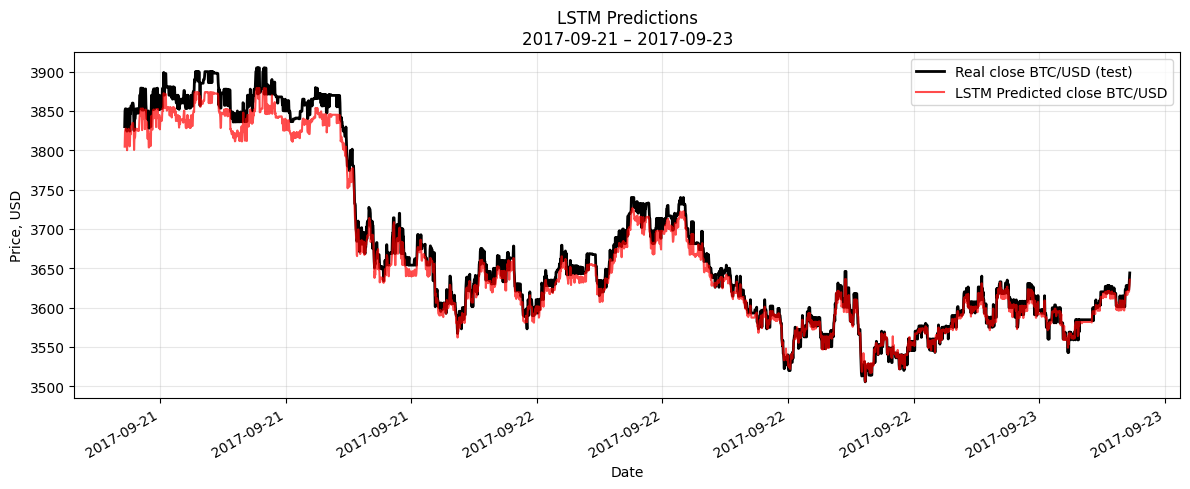

In [18]:
model_path = 'best_model_2_50.keras'
model = load_model(model_path)

slice_df = data1.iloc[train_size + test_size:train_size + test_size + future_size].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_future.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
#5 дней
y = data1['low']
train_size = 40000
test_size = 10000
future_size = 7201

train_end = train_size
test_end = train_size + test_size
future_end = train_size + test_size + future_size

X_future = X.iloc[train_size + test_size:train_size + test_size + future_size].copy()
y_future = y.iloc[train_size + test_size:train_size + test_size + future_size]

X_future_num = X_future[features_num].values
X_future_scaled = scaler.transform(X_future_num)
X_future_lstm = X_future_scaled.reshape(X_future_scaled.shape[0],
                                        X_future_scaled.shape[1],
                                        1).astype('float32')

print("\nДАТЫ X_future_lstm:")
print(f"Future начало: {pd.to_datetime(X_future['timestamp'].iloc[0] * 1_000_000)}")
print(f"Future конец:   {pd.to_datetime(X_future['timestamp'].iloc[-1] * 1_000_000)}")



ДАТЫ X_future_lstm:
Future начало: 2017-09-21 04:19:00
Future конец:   2017-09-26 04:19:00


slice_df shape: (7201, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (7201, 9, 1)


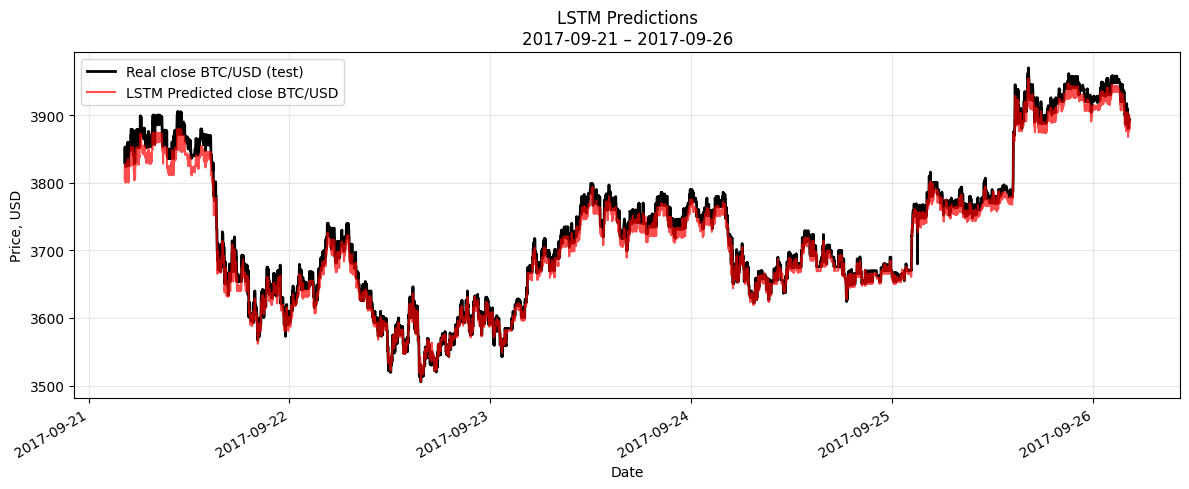

In [20]:
slice_df = data1.iloc[train_size + test_size:train_size + test_size + future_size].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_future.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
#7 дней
y = data1['low']
train_size = 40000
test_size = 10000
future_size = 10081

train_end = train_size
test_end = train_size + test_size
future_end = train_size + test_size + future_size

X_future = X.iloc[train_size + test_size:train_size + test_size + future_size].copy()
y_future = y.iloc[train_size + test_size:train_size + test_size + future_size]

X_future_num = X_future[features_num].values
X_future_scaled = scaler.transform(X_future_num)
X_future_lstm = X_future_scaled.reshape(X_future_scaled.shape[0],
                                        X_future_scaled.shape[1],
                                        1).astype('float32')

print("\nДАТЫ X_future_lstm:")
print(f"Future начало: {pd.to_datetime(X_future['timestamp'].iloc[0] * 1_000_000)}")
print(f"Future конец:   {pd.to_datetime(X_future['timestamp'].iloc[-1] * 1_000_000)}")



ДАТЫ X_future_lstm:
Future начало: 2017-09-21 04:19:00
Future конец:   2017-09-28 04:19:00


slice_df shape: (10081, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10081, 9, 1)


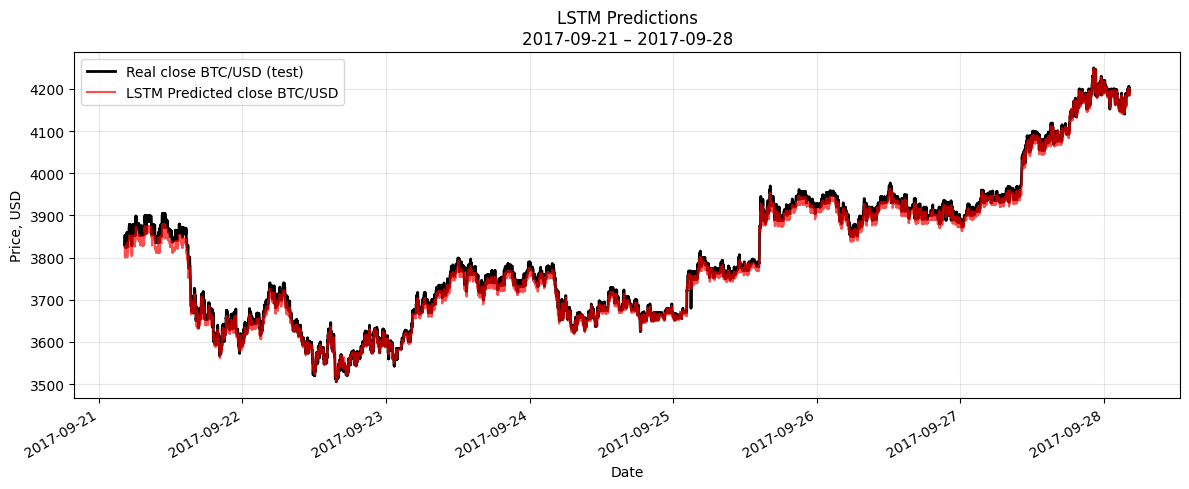

In [22]:
slice_df = data1.iloc[train_size + test_size:train_size + test_size + future_size].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_future.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
#10 дней
y = data1['low']
train_size = 40000
test_size = 10000
future_size = 14401

train_end = train_size
test_end = train_size + test_size
future_end = train_size + test_size + future_size

X_future = X.iloc[train_size + test_size:train_size + test_size + future_size].copy()
y_future = y.iloc[train_size + test_size:train_size + test_size + future_size]

X_future_num = X_future[features_num].values
X_future_scaled = scaler.transform(X_future_num)
X_future_lstm = X_future_scaled.reshape(X_future_scaled.shape[0],
                                        X_future_scaled.shape[1],
                                        1).astype('float32')

print("\nДАТЫ X_future_lstm:")
print(f"Future начало: {pd.to_datetime(X_future['timestamp'].iloc[0] * 1_000_000)}")
print(f"Future конец:   {pd.to_datetime(X_future['timestamp'].iloc[-1] * 1_000_000)}")



ДАТЫ X_future_lstm:
Future начало: 2017-09-21 04:19:00
Future конец:   2017-10-01 04:19:00


slice_df shape: (14401, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (14401, 9, 1)


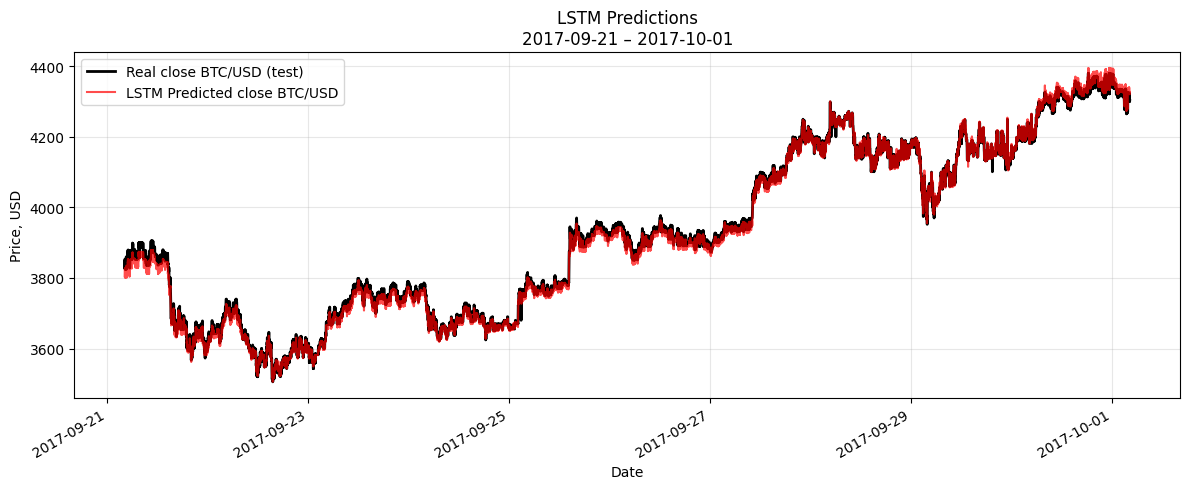

In [24]:
slice_df = data1.iloc[train_size + test_size:train_size + test_size + future_size].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_future.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()